In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 23/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out


def prior_transform(u):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [0.8, 1.3]
    # alim = [0.3, 0.99]
    # p0lim = [8.0, 11.0]
    # e0lim = [0.2, 0.5]
    # qSlim = [0.0, np.pi]
    # phiSlim = [0.0, 2 * np.pi]
    # logm1lim = [5.6,  6.4]
    # logm2lim = [1.7, 2.3]
    # alim = [0.3, 0.99]
    # p0lim = [13.5, 16.5]
    # e0lim = [0.6, 0.9]
    # cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    # phiSlim = [0.0, 2 * np.pi]

    # EMRI C
    logm1lim = [6.15,  6.95]
    logm2lim = [1.60,  2.20]
    alim = [0.70,  0.999]
    p0lim = [5.89,  8.89]
    e0lim = [0.17,  0.47]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]

    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # EMRI C
    logm1lim = [6.15,  6.95]
    logm2lim = [1.60,  2.20]
    alim = [0.70,  0.999]
    p0lim = [5.89,  8.89]
    e0lim = [0.17,  0.47]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=10s, T=1.9166666666666667yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_c/stage1_merge_s12/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 9.01119818e-08,  1.66175922e-07,  1.98964151e-07,
         -7.87193937e-08, -1.42385432e-06,  2.20246252e-06,
         -4.89511922e-07],
        [ 1.66175922e-07,  3.15007995e-07,  3.67752847e-07,
         -1.31445488e-07, -2.75864258e-06,  3.69380041e-06,
         -9.93825293e-07],
        [ 1.98964151e-07,  3.67752847e-07,  4.43433710e-07,
         -1.78103857e-07, -3.09208761e-06,  4.60977320e-06,
         -1.05880923e-06],
        [-7.87193937e-08, -1.31445488e-07, -1.78103857e-07,
          2.74574672e-07,  1.04414458e-06, -1.94894515e-06,
          1.03809948e-06],
        [-1.42385432e-06, -2.75864258e-06, -3.09208761e-06,
          1.04414458e-06,  2.61884748e-05, -1.82933166e-05,
          8.25301366e-06],
        [ 2.20246252e-06,  3.69380041e-06,  4.60977320e-06,
         -1.94894515e-06, -1.82933166e-05,  2.68333295e-03,
         -3.14684416e-04],
        [-4.89511922e-07, -9.93825293e-07, -1.05880923e-06,
          1.03809948e-06,  8.25301366e-06, -3.14684416e-04

In [5]:
len(sampler.now_covariances)

6

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.54870539, 1.90312338, 0.94977017, 7.3903245 , 0.31713678,
        0.37063354, 2.67380252]])

In [7]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 6.54448778,  1.90508738,  0.94923777,  7.44386316,  0.31709113,
        -0.22733725,  0.04380627]])

In [8]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[6.59532653, 1.90415399, 0.960505  , 6.96304119, 0.19227581,
        0.17550249, 2.04596726]])

In [9]:
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4

array([[ 6.60538399,  1.90002082,  0.96121041,  6.86087512,  0.21681789,
        -0.57879969,  5.7314225 ]])

In [10]:
maxld_pt5 = prior_transform(proc_pt[4][np.argmax(logden_list)].reshape(1, -1))
maxld_pt5

array([[6.49876235, 1.90779461, 0.93629186, 7.88430611, 0.36746468,
        0.46887171, 2.13145067]])

In [11]:
maxld_pt6 = prior_transform(proc_pt[5][np.argmax(logden_list)].reshape(1, -1))
maxld_pt6

array([[ 6.47975512,  1.91607258,  0.93314299,  8.12638926,  0.36861937,
        -0.27287653,  5.9893279 ]])

In [12]:
log_density(maxld_pt1)

array([118.024466])

In [13]:
log_density(maxld_pt2)

array([52.99960753])

In [14]:
log_density(maxld_pt3)

array([59.43578993])

In [15]:
log_density(maxld_pt4)

array([42.65473823])

In [16]:
log_density(maxld_pt5)

array([57.18934951])

In [17]:
log_density(maxld_pt6)

array([56.15589432])

In [18]:
log_density([param_true])

array([123.54490623])

In [19]:
param_ranges = [(6.15,  6.95),
                (1.60,  2.20),
                (0.70,  0.999),
                (5.89,  8.89),
                (0.17,  0.47),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(6.15, 6.95),
 (1.6, 2.2),
 (0.7, 0.999),
 (5.89, 8.89),
 (0.17, 0.47),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [20]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

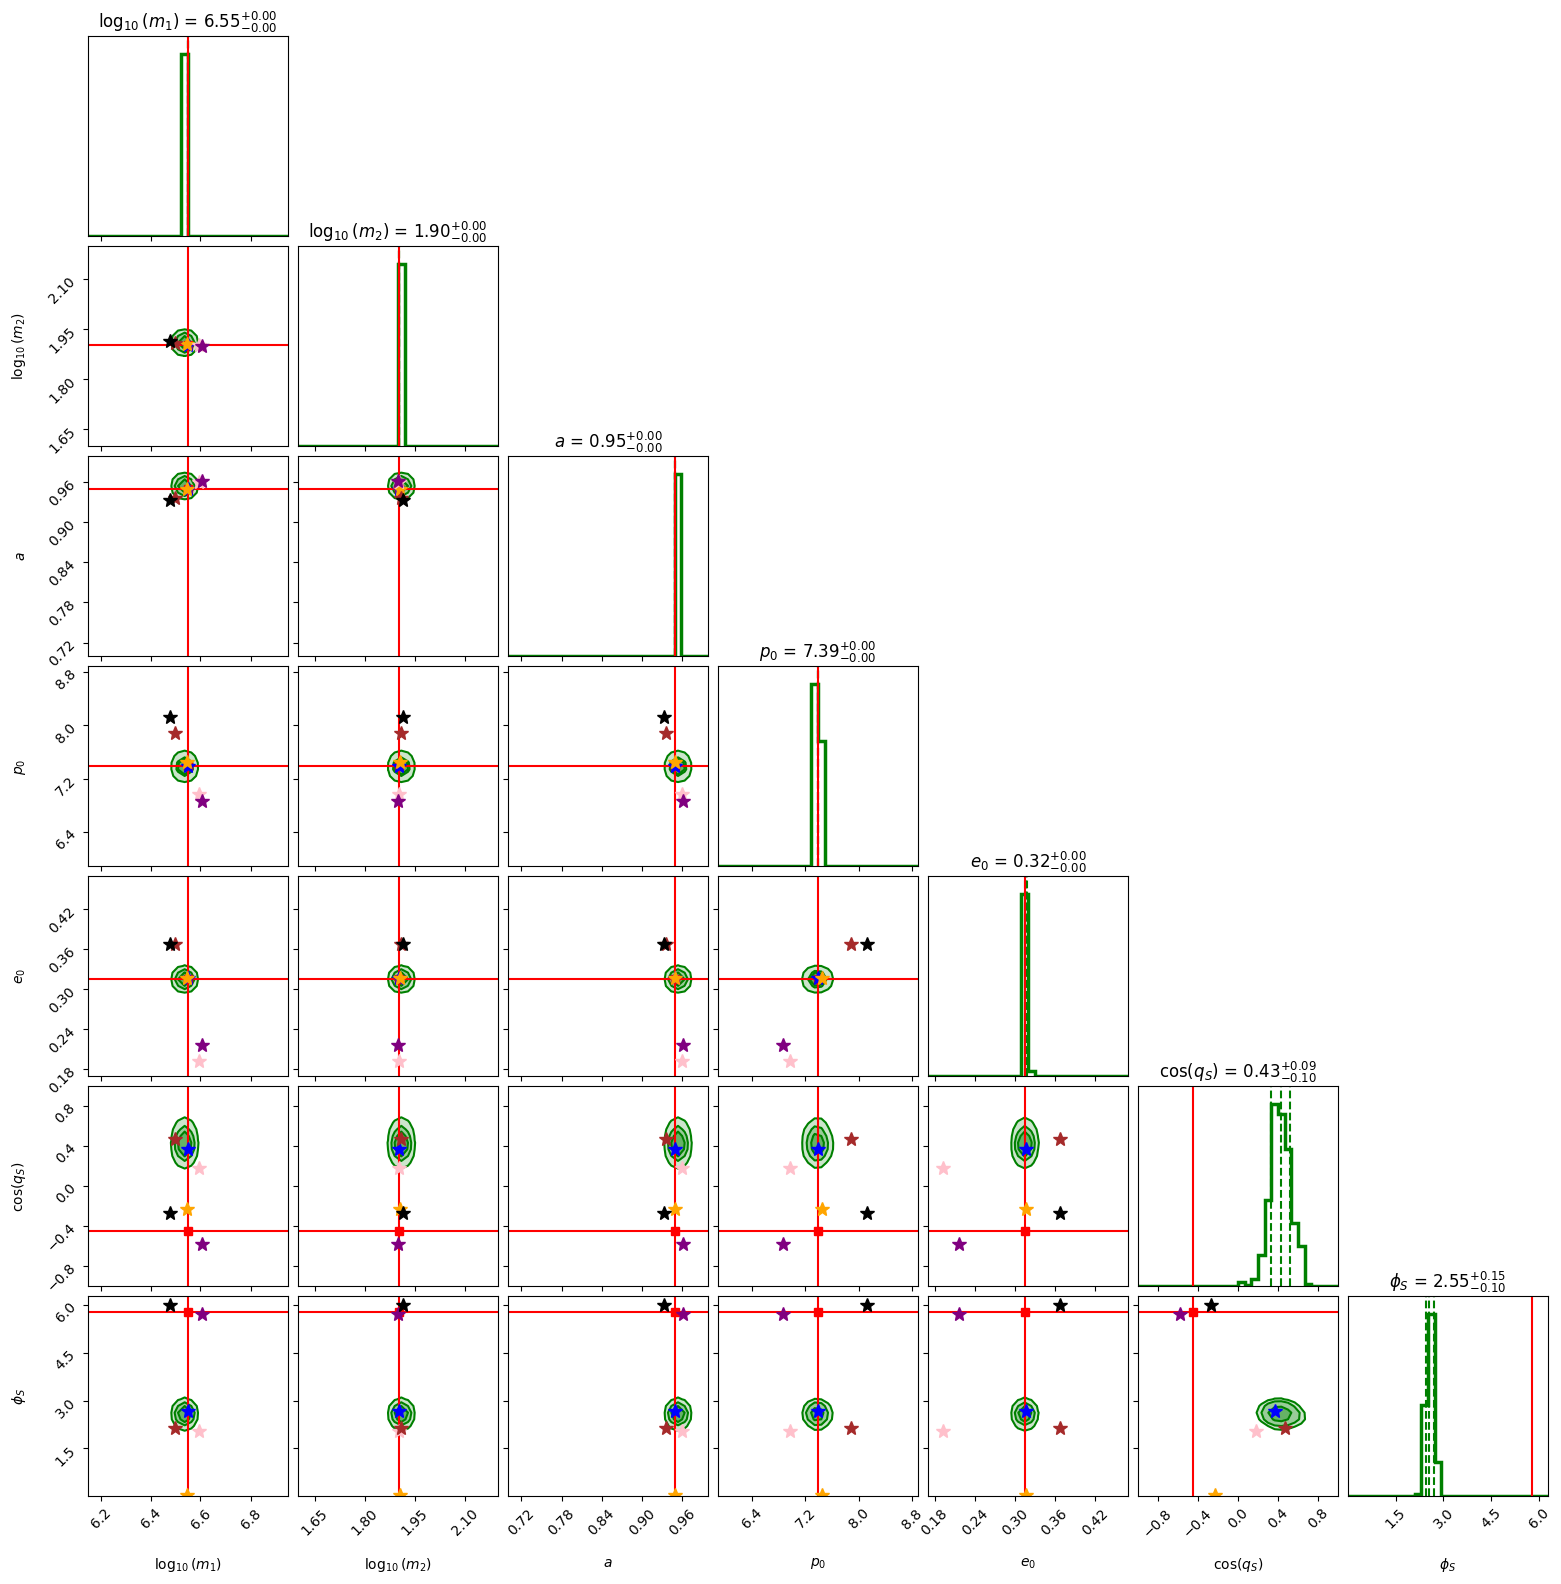

In [21]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='pink', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
                       color='purple', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt5.reshape(1, -1),
                       color='brown', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt6.reshape(1, -1),
                       color='black', marker='*', ms=10,
                       reverse=False)

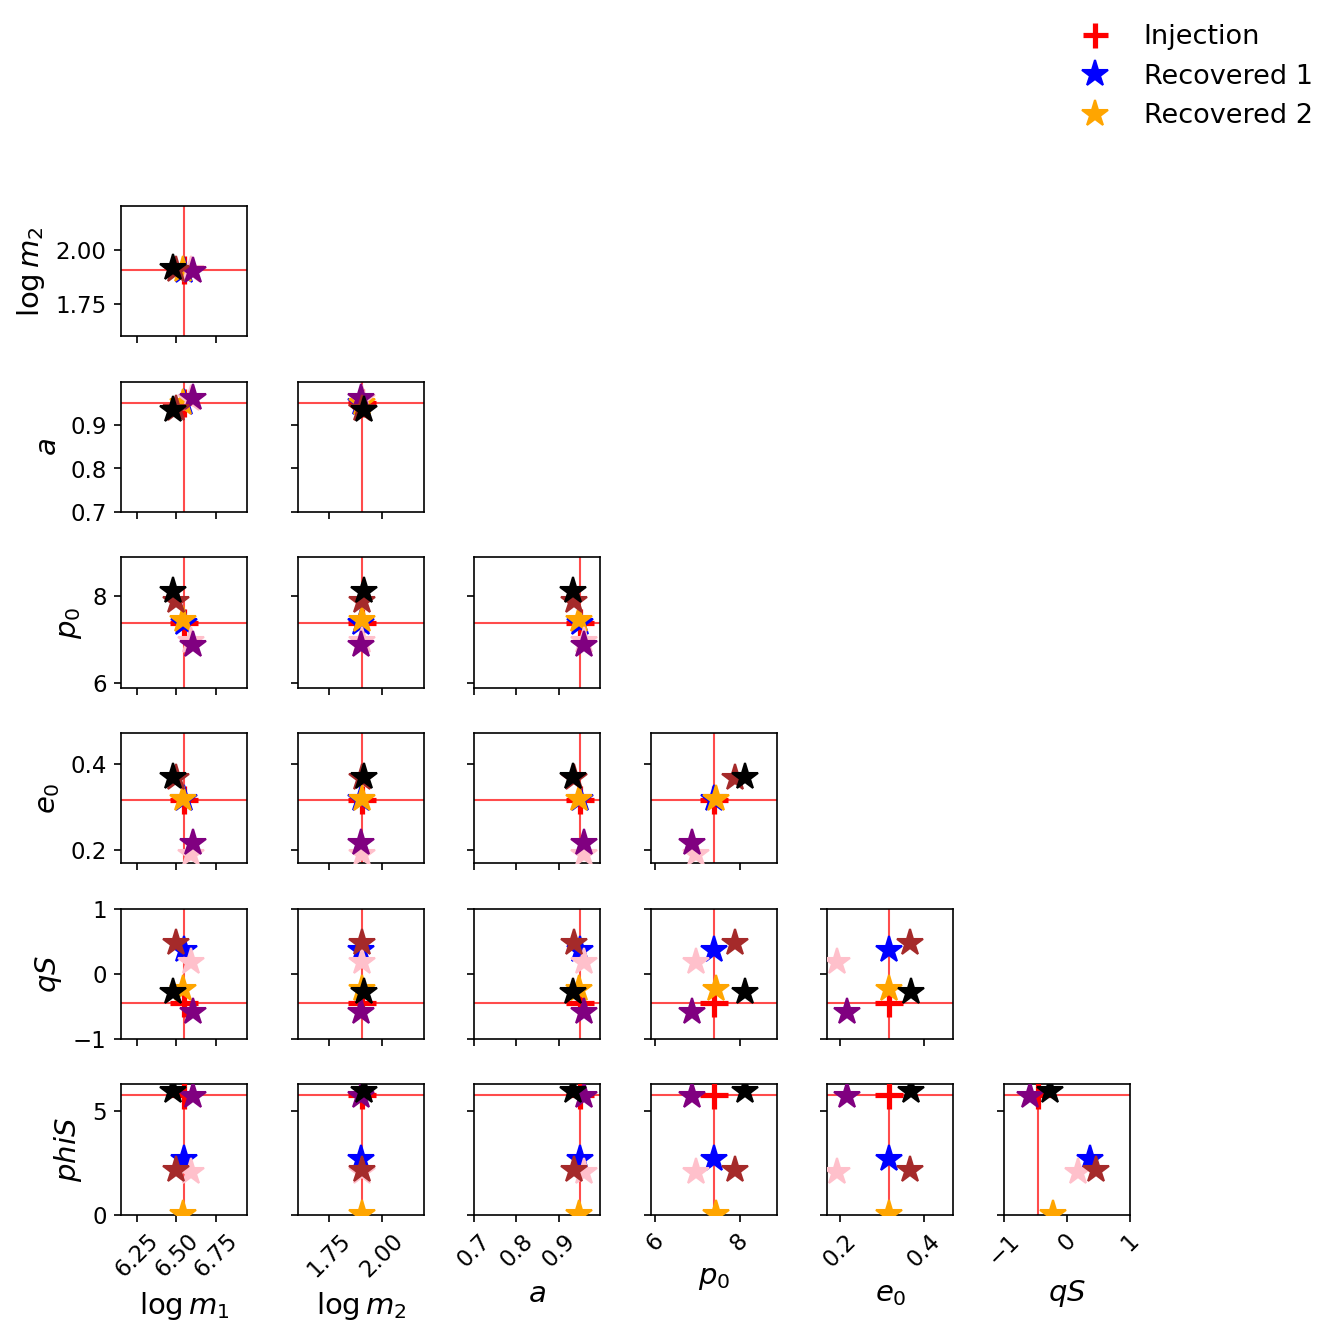

In [23]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()
maxld_pt5  = np.asarray(maxld_pt5).ravel()
maxld_pt6  = np.asarray(maxld_pt6).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
                ms=13, zorder=4)
        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='purple',
                ms=13, zorder=4)
        ax.plot(maxld_pt5[j], maxld_pt5[i], '*', color='brown',
                ms=13, zorder=4)
        ax.plot(maxld_pt6[j], maxld_pt6[i], '*', color='black',
                ms=13, zorder=4)
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [24]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.54870539, 1.90312338, 0.94977017, 7.3903245 , 0.31713678,
        0.37063354, 2.67380252]])

In [25]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [26]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [27]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


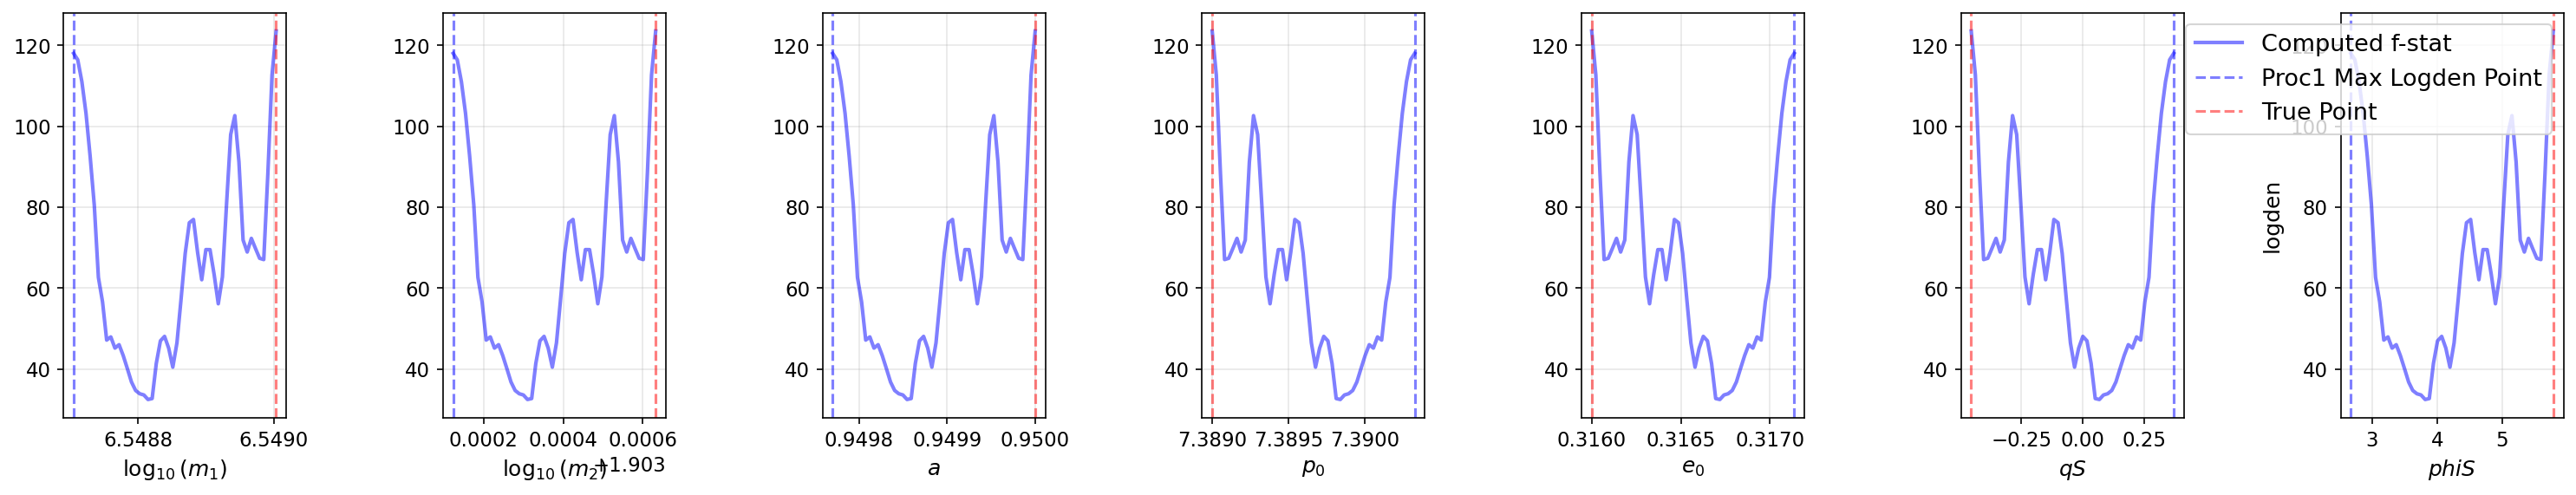

In [28]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [29]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [30]:
maxld_pt1

array([6.54870539, 1.90312338, 0.94977017, 7.3903245 , 0.31713678,
       0.37063354, 2.67380252])